# DAGs, $S^{N-2}$, and Barycentric Rounding

This notebook implements and visualises the full rounding pipeline $\hat{\theta}(\vartheta)$
that converts a continuous parameter $\vartheta \in S^{N-2}$ into a discrete DAG.

**Structure:**
1. Core algorithm: `closest_barycenter`, `normalize_to_simplex`, `rounding_map`
2. **Fig 1** — The braid arrangement on $S^1$ ($N=3$): 6 chambers = 6 complete DAGs
3. **Fig 2** — Voronoi regions of the 7 face barycenters in $\Delta_2$ ($N=3$)
4. **Fig 3** — Full pipeline trace for a random point ($N=4$)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 12,
    'figure.dpi': 110,
})
np.random.seed(42)

# All figures are saved here automatically when the notebook is run
FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)
print(f'Figures will be saved to: {os.path.abspath(FIGDIR)}/')

## Algorithm implementation

Three functions implement the pipeline:

* **`closest_barycenter(p)`** — given $p \in \Delta_{N-1}$, finds the face whose barycenter is nearest.
  Uses the recurrence $\widetilde D_k = S_k - k\,\alpha_{k+1} - \tfrac{1}{2}$,
  which is non-decreasing.  The threshold $k$ is the first index with $\widetilde D_k \ge 0$.

* **`normalize_to_simplex(x)`** — maps a sorted point $x \in W_+\subset S^{N-2}$
  to $\Delta_{N-1}$ via $\varphi(x)_i = (x_i - x_N)/({-N x_N})$.

* **`rounding_map(x)`** — the complete four-step pipeline.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 3 helper: find the nearest face barycenter inside Delta_{N-1}
# ─────────────────────────────────────────────────────────────────────────────

def closest_barycenter(p):
    """
    Given p in Delta_{N-1}, return (k, top_indices) such that c_{top_indices}
    (the barycenter of the face on those k nodes) is nearest to p.

    The key quantity is
        D̃_l = S_l − l·α_{l+1} − 1/2,   S_l = α_1 + … + α_l
    which is non-decreasing (D̃_{l+1} − D̃_l = (l+1)(α_l − α_{l+1}) ≥ 0).
    The nearest barycenter is the prefix face of size k, where k is the
    smallest index with D̃_k ≥ 0.
    """
    p = np.asarray(p, dtype=float)
    N = len(p)
    j = np.argsort(p)[::-1]        # j[l] = index of (l+1)-th largest coord
    ps = p[j]                      # sorted descending

    D = ps[0] - (ps[1] if N > 1 else 0.0) - 0.5   # D̃_1
    k = 1
    while D < 0 and k < N:
        k += 1
        nxt = ps[k] if k < N else 0.0
        D += k * (ps[k - 1] - nxt)                # D̃_k = D̃_{k-1} + k(α_{j_k} − α_{j_{k+1}})

    return k, j[:k]


# ─────────────────────────────────────────────────────────────────────────────
# Step 2 helper: normalise a W_+-point on S^{N-2} to Delta_{N-1}
# ─────────────────────────────────────────────────────────────────────────────

def normalize_to_simplex(x_desc):
    """
    Map x ∈ W_+ (sorted descending, with Σ x_i = 0) to Delta_{N-1}.

    φ(x)_i = (x_i − x_min) / (−N·x_min)

    x ∈ S^{N-2} ⟹ x ≠ 0 ⟹ x_min < 0 ⟹ denominator > 0.
    Output: sum = 1, all entries ≥ 0, last entry = 0.
    """
    x = np.asarray(x_desc, dtype=float)
    x_min = x[-1]                  # minimum (last after sorting desc)
    denom = -len(x) * x_min
    if denom < 1e-12:
        return np.ones(len(x)) / len(x)
    return (x - x_min) / denom


# ─────────────────────────────────────────────────────────────────────────────
# Full rounding map
# ─────────────────────────────────────────────────────────────────────────────

def rounding_map(x):
    """
    x ∈ S^{N-2} (a vector in R^N with Σ x_i = 0, |x| = 1)
    ──►  hat_theta(x): a discrete DAG on {0, …, N-1}.

    Four steps:
      1. Sort x descending → permutation sigma (chamber identification).
      2. Normalise to Delta_{N-1} via phi.
      3. Find nearest face barycenter → threshold k.
      4. Decode: edges from bottom group B to top group T.

    Returns a dict with keys: sigma, p, k, top, bottom, edges.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    # Step 1 — sort
    sigma = np.argsort(x)[::-1]           # sigma[0] = index with largest x

    # Step 2 — normalise
    p = normalize_to_simplex(x[sigma])

    # Step 3 — nearest barycenter
    k, _ = closest_barycenter(p)

    # Step 4 — decode
    top    = sigma[:k]
    bottom = sigma[k:]
    edges  = [(int(b), int(t)) for b in bottom for t in top]

    return dict(sigma=sigma, p=p, k=k, top=top, bottom=bottom, edges=edges)


# ─────────────────────────────────────────────────────────────────────────────
# Utility: draw a DAG with networkx
# ─────────────────────────────────────────────────────────────────────────────

def draw_dag(ax, N, result, title=''):
    """Draw the DAG encoded in 'result' (output of rounding_map)."""
    G = nx.DiGraph()
    G.add_nodes_from(range(N))
    G.add_edges_from(result['edges'])

    top_set    = set(result['top'].tolist())
    bottom_set = set(result['bottom'].tolist())

    # Layout: top group at y=0.75, bottom group at y=0.25
    pos = {}
    top_list = sorted(top_set)
    bot_list = sorted(bottom_set)
    for i, t in enumerate(top_list):
        pos[t] = ((i + 0.5) / max(len(top_list), 1), 0.75)
    for i, b in enumerate(bot_list):
        pos[b] = ((i + 0.5) / max(len(bot_list), 1), 0.25)
    if not pos:
        pos = nx.spring_layout(G, seed=0)

    colors = ['#3498db' if n in top_set else '#e74c3c' for n in G.nodes()]
    labels = {n: f'$v_{n+1}$' for n in G.nodes()}

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors,
                           node_size=700, alpha=0.92)
    nx.draw_networkx_labels(G, pos, labels, ax=ax,
                            font_size=11, font_color='white', font_weight='bold')
    if result['edges']:
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#2c3e50',
                               width=2.0, arrowsize=22,
                               connectionstyle='arc3,rad=0.08')

    th = mpatches.Patch(color='#3498db',
                        label=f'Top $T$ = nodes {{{" ,".join(str(t+1) for t in top_list)}}}')
    bh = mpatches.Patch(color='#e74c3c',
                        label=f'Bottom $B$ = nodes {{{" ,".join(str(b+1) for b in bot_list)}}}')
    ax.legend(handles=[th, bh], loc='lower center', fontsize=9, framealpha=0.9)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0.0, 1.0)
    ax.axis('off')


print('Algorithm loaded. Functions: closest_barycenter, normalize_to_simplex, rounding_map, draw_dag')

Algorithm loaded. Functions: closest_barycenter, normalize_to_simplex, rounding_map, draw_dag


---
## Figure 1 — Braid arrangement on $S^1$ ($N = 3$)

**What is shown.** For $N=3$, the hyperplane $H_0 = \{x_1+x_2+x_3=0\}$ is a 2-dimensional
plane in $\mathbb{R}^3$, and $S^1 = S^{N-2}$ is just its unit circle.
The three tie-hyperplanes $\{x_i = x_j\}$ intersect $S^1$ at **six boundary points**
(three pairs of antipodal points), cutting the circle into **6 coloured arcs** (chambers).

**Left panel — the chambers.**  
Each arc corresponds to one strict linear ordering of the three coordinates, e.g.
$x_1 > x_2 > x_3$, $x_1 > x_3 > x_2$, and so on.  
By Theorem 1 (Section 2 of the notes), each linear ordering encodes exactly one
*complete* DAG on 3 nodes: the node with the largest $x$-coordinate is the unique sink
of all edges.  The six arcs thus tile $S^1$ by the six complete DAGs on $\{1,2,3\}$.  
White dots mark the boundary points, where two coordinates are equal — these correspond
to partial orders (two nodes share a tier).

**Right panel — the rounding map $\hat\theta(\vartheta)$.**  
The same circle is redrawn, coloured by the output of `rounding_map`.
Two saturation levels indicate the size $k$ of the top-group:

* **Saturated colour** ($k=1$): the leading coordinate is so much larger than the
  second that the algorithm immediately stops.  Only one node sits in the top group $T$,
  so the decoded DAG is a *star*: every other node sends an edge to this single sink.
* **Faded colour** ($k=2$): the two largest coordinates are close, so the algorithm
  extends the top group to size 2.  The DAG is *v-shaped*: the third node sends an
  edge to each of the two "winners", and there are no edges between the winners themselves.

The small **mini-DAG diagrams** placed around the circle show the actual graph
decoded at the midpoint of each chamber.  Nodes are arranged in two rows (top group
$T$ in the upper row, bottom group $B$ below), with directed edges from $B$ to $T$.

**Key take-away.** The geometry of $S^1$ *already encodes all DAG structure*:
chamber boundaries are precisely the places where the rounding output changes,
and the saturation gradient shows how "confident" the rounding is within each chamber.

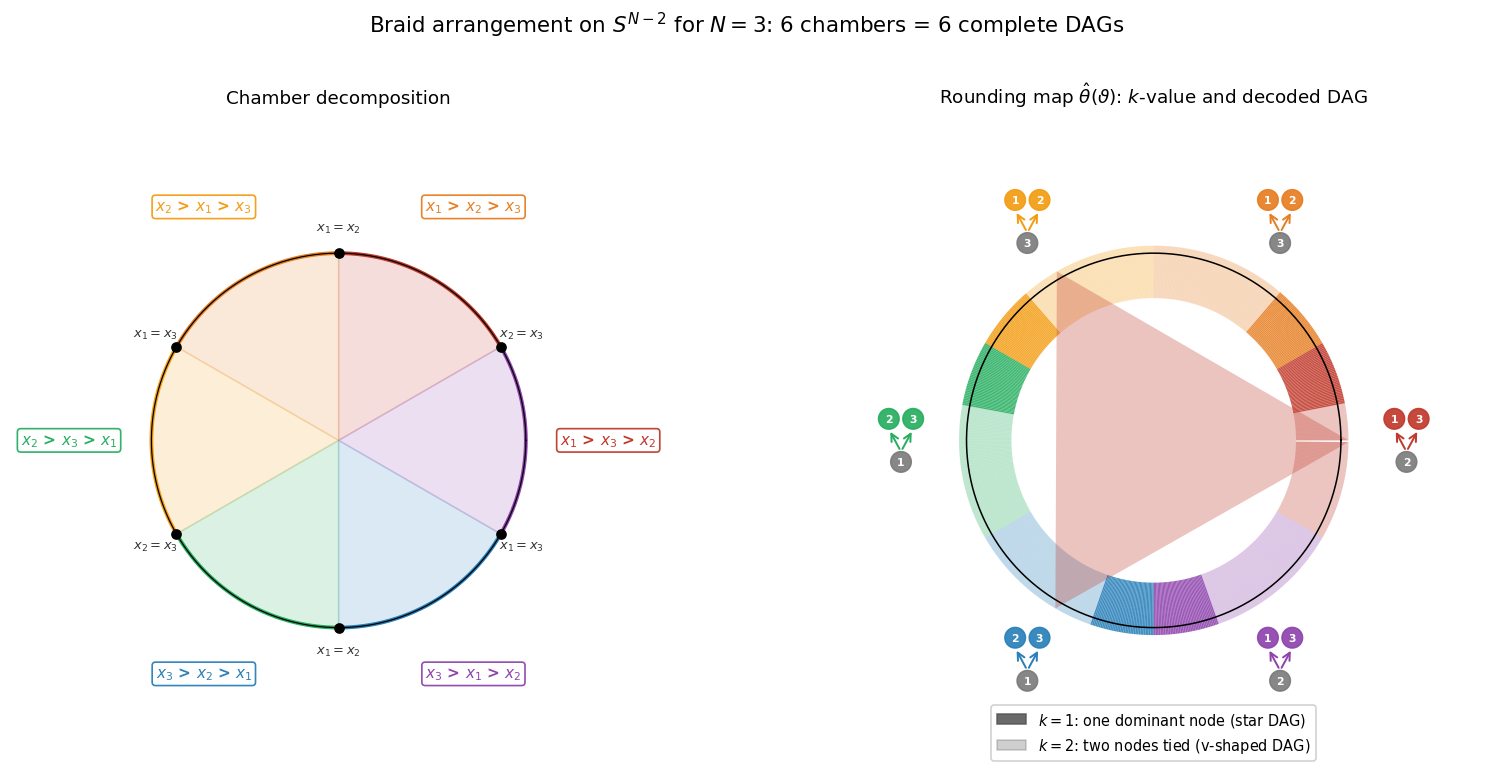

In [3]:
# Embedding: S¹ ⊂ H₀ = {x₁+x₂+x₃=0}  using orthonormal basis u₁, u₂
u1 = np.array([ 1., -1.,  0.]) / np.sqrt(2)
u2 = np.array([ 1.,  1., -2.]) / np.sqrt(6)

def s1_pt(theta):
    return np.cos(theta)*u1 + np.sin(theta)*u2

# Boundary angles (where two coordinates are equal)
#   x₂=x₃ at 30° and 210°,  x₁=x₂ at 90° and 270°,  x₁=x₃ at 150° and 330°
bnd     = np.radians([30, 90, 150, 210, 270, 330])
mid     = np.radians([ 0, 60, 120, 180, 240, 300])
tie_lbl = ['$x_2{=}x_3$','$x_1{=}x_2$','$x_1{=}x_3$',
           '$x_2{=}x_3$','$x_1{=}x_2$','$x_1{=}x_3$']
pal = ['#c0392b','#e67e22','#f39c12','#27ae60','#2980b9','#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Braid arrangement on $S^{N-2}$ for $N=3$: 6 chambers = 6 complete DAGs',
             fontsize=14, y=1.01)

# ── left: chamber structure ───────────────────────────────────────────────────
ax = axes[0]
ax.set_aspect('equal'); ax.axis('off')
ax.set_xlim(-1.75, 1.75); ax.set_ylim(-1.75, 1.75)

for i, col in enumerate(pal):
    ts = bnd[i]; te = bnd[(i+1) % 6]
    if te <= ts: te += 2*np.pi
    th = np.linspace(ts, te, 300)
    ax.fill(np.r_[0, np.cos(th), 0], np.r_[0, np.sin(th), 0], color=col, alpha=0.17)
    ax.plot(np.cos(th), np.sin(th), '-', color=col, lw=2.5)

th_full = np.linspace(0, 2*np.pi, 1000)
ax.plot(np.cos(th_full), np.sin(th_full), 'k-', lw=0.8)

for th, col in zip(mid, pal):
    x3 = s1_pt(th)
    order = np.argsort(x3)[::-1]
    label = ' > '.join(f'$x_{o+1}$' for o in order)
    r = 1.44
    ax.text(r*np.cos(th), r*np.sin(th), label,
            ha='center', va='center', fontsize=10, color=col, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.22', fc='white', ec=col, alpha=0.95, lw=1.1))

for th, lbl in zip(bnd, tie_lbl):
    ax.plot(np.cos(th), np.sin(th), 'ko', ms=6, zorder=6)
    ax.text(1.13*np.cos(th), 1.13*np.sin(th), lbl,
            ha='center', va='center', fontsize=8.5, color='#333')

ax.set_title('Chamber decomposition', fontsize=12, pad=6)

# ── right: rounding map (k-values + mini-DAGs) ───────────────────────────────
ax2 = axes[1]
ax2.set_aspect('equal'); ax2.axis('off')
ax2.set_xlim(-1.75, 1.75); ax2.set_ylim(-1.75, 1.75)

n_samp = 720
thetas = np.linspace(0, 2*np.pi, n_samp, endpoint=False)

k_arr = []
for th in thetas:
    x = s1_pt(th)
    k_arr.append(rounding_map(x)['k'])
k_arr = np.array(k_arr)

# Chamber index for each sample
bnd_adj = np.sort(bnd % (2*np.pi))
ch_idx = np.searchsorted(bnd_adj, thetas % (2*np.pi), side='right') % 6

# Draw coloured ring: saturated = k=1, faded = k=2
for i in range(n_samp):
    th0 = thetas[i]; th1 = thetas[(i+1) % n_samp]
    col = pal[ch_idx[i]]
    alpha = 0.88 if k_arr[i] == 1 else 0.30
    r_i, r_o = 0.76, 1.04
    arc = np.linspace(th0, th1, 4)
    xp = np.r_[r_i*np.cos(th0), r_o*np.cos(arc), r_i*np.cos(th1)]
    yp = np.r_[r_i*np.sin(th0), r_o*np.sin(arc), r_i*np.sin(th1)]
    ax2.fill(xp, yp, color=col, alpha=alpha, linewidth=0)

ax2.plot(np.cos(th_full), np.sin(th_full), 'k-', lw=1.0)

# Mini-DAG diagrams at each chamber midpoint
r_node = 0.055
for th, col in zip(mid, pal):
    res = rounding_map(s1_pt(th))
    top_l = [t+1 for t in sorted(res['top'])]
    bot_l = [b+1 for b in sorted(res['bottom'])]
    cx, cy = 1.35*np.cos(th), 1.35*np.sin(th)

    def node_xy(nodes, y_off):
        n = len(nodes)
        return [(cx + (i - (n-1)/2)*0.13, cy + y_off) for i, _ in enumerate(nodes)]

    top_xy = node_xy(top_l, +0.115)
    bot_xy = node_xy(bot_l, -0.115)

    for (nx_, ny_), label in zip(top_xy, top_l):
        ax2.add_patch(plt.Circle((nx_, ny_), r_node, color=col, alpha=0.92, zorder=8))
        ax2.text(nx_, ny_, str(label), ha='center', va='center',
                 fontsize=7, color='white', fontweight='bold', zorder=9)

    for (nx_, ny_), label in zip(bot_xy, bot_l):
        ax2.add_patch(plt.Circle((nx_, ny_), r_node, color='#777', alpha=0.88, zorder=8))
        ax2.text(nx_, ny_, str(label), ha='center', va='center',
                 fontsize=7, color='white', fontweight='bold', zorder=9)

    for b_idx, t_idx in res['edges']:
        bi = sorted(res['bottom'].tolist()).index(b_idx)
        ti = sorted(res['top'].tolist()).index(t_idx)
        bx_, by_ = bot_xy[bi]; tx_, ty_ = top_xy[ti]
        ax2.annotate('', xy=(tx_, ty_ - r_node), xytext=(bx_, by_ + r_node),
                     arrowprops=dict(arrowstyle='->', color=col, lw=1.3), zorder=9)

# Legend
h1 = mpatches.Patch(color='#555', alpha=0.88, label='$k=1$: one dominant node (star DAG)')
h2 = mpatches.Patch(color='#555', alpha=0.28, label='$k=2$: two nodes tied (v-shaped DAG)')
ax2.legend(handles=[h1, h2], loc='lower center', fontsize=9.5, framealpha=0.95)
ax2.set_title('Rounding map $\\hat{\\theta}(\\vartheta)$: $k$-value and decoded DAG', fontsize=12, pad=6)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig1_s1_chambers.pdf', bbox_inches='tight')
plt.savefig(f'{FIGDIR}/fig1_s1_chambers.png', bbox_inches='tight', dpi=150)
print(f'Saved: {FIGDIR}/fig1_s1_chambers.pdf  +  .png')
plt.show()

---
## Figure 2 — Nearest-barycenter Voronoi regions in $\Delta_2$ ($N = 3$)

**What is shown.** The standard simplex $\Delta_2$ lives in the plane
$\{\alpha_1+\alpha_2+\alpha_3=1,\; \alpha_i\ge 0\}$.
Its **7 face barycenters** are:
* three *vertices* $c_{\{1\}}{=}(1,0,0)$, $c_{\{2\}}{=}(0,1,0)$, $c_{\{3\}}{=}(0,0,1)$;
* three *edge midpoints* $c_{\{1,2\}}{=}(\tfrac12,\tfrac12,0)$, $c_{\{1,3\}}{=}(\tfrac12,0,\tfrac12)$, $c_{\{2,3\}}{=}(0,\tfrac12,\tfrac12)$;
* one *centroid* $c_{\{1,2,3\}}{=}(\tfrac13,\tfrac13,\tfrac13)$.

Each barycenter corresponds to a DAG structure: the face $\{i_1,\ldots,i_k\}$
encodes the bipartite partial order "nodes $\{i_1,\ldots,i_k\}$ dominate all others."

**Left panel — Voronoi diagram.**  
The simplex is filled with 30 000 random points, each coloured by its nearest barycenter
(the output of `closest_barycenter`).  The resulting regions are the *Voronoi cells*
of the seven barycenters inside the simplex.

Their shapes can be understood directly from the threshold formula $\widetilde D_k$:
* **Vertex region** ($k=1$, 3 corner patches): the largest coordinate exceeds the
  second by $\ge\tfrac12$. One node overwhelmingly dominates, so the nearest point
  is a vertex — a star DAG with one sink.
* **Edge-midpoint region** ($k=2$, 3 elongated patches): the top two coordinates
  are close together, but both are well above the third. The algorithm extends the
  top group to 2, giving a v-shaped DAG with two sinks.
* **Centroid region** ($k=3$, central patch): all three coordinates are nearly equal.
  No node clearly wins, so the nearest point is the centroid — the empty DAG,
  no resolved causal order.

Notice that the boundaries between regions are straight lines (hyperplanes), confirming
that the Voronoi diagram is polyhedral.

**Right panel — worked example.**  
A specific point $p\in\Delta_2$ (shown as a large dot) is given, along with an arrow
pointing to its nearest barycenter.  The text box records the $\widetilde D_l$ trace:
the algorithm computes $\widetilde D_1$, checks the sign, and stops (or continues),
exactly as described in Section 4 of the notes.  Reading the trace step-by-step is
the clearest way to see *why* the algorithm terminates where it does.nodes tied, third is negligible.
* **Center region** ($k=3$): $\alpha_3 > \frac{1}{6}$ — all three nodes carry significant weight.

The right panel demonstrates the algorithm on a specific example point.

Computing Voronoi regions...
Done.


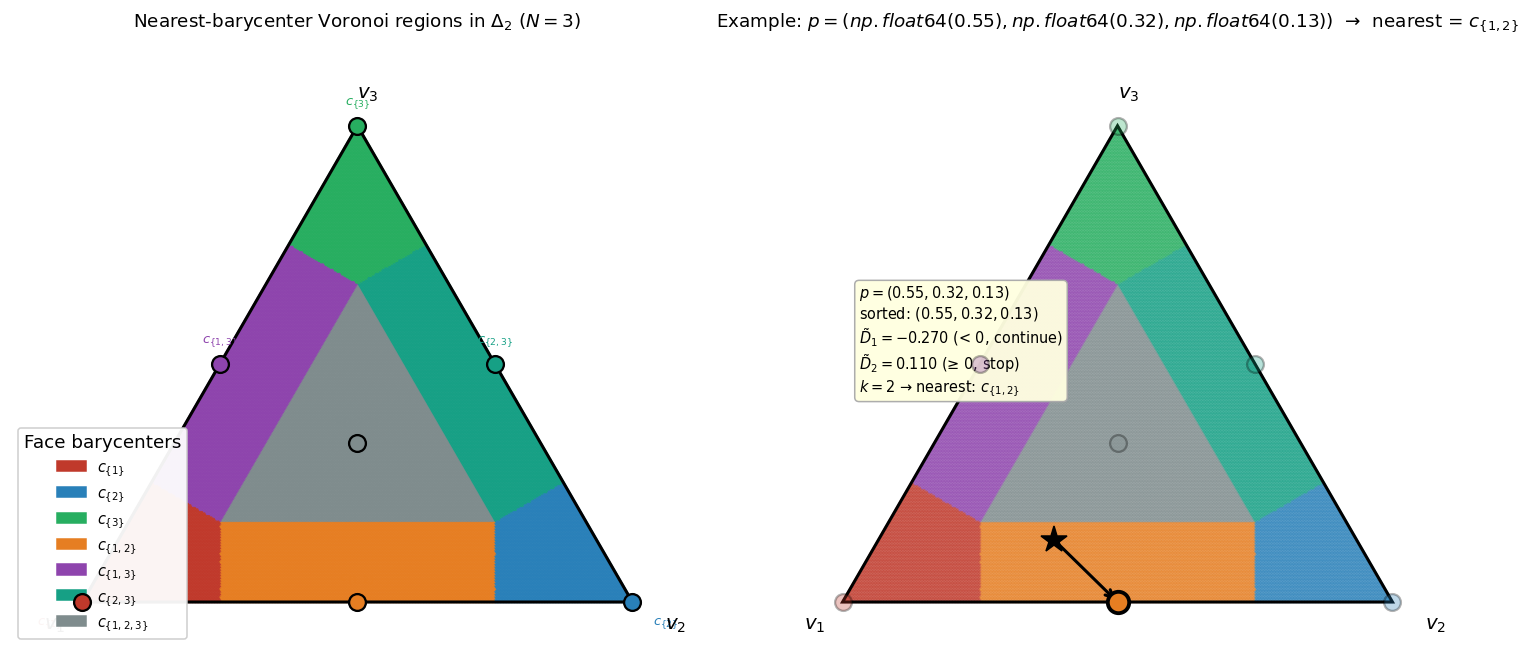

In [4]:
# Triangle vertices in 2D (standard barycentric embedding)
TRI = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3)/2]])

def bary2d(alpha):
    """Barycentric -> 2D Cartesian."""
    a = np.asarray(alpha)
    if a.ndim == 1:
        return a @ TRI
    return a @ TRI

# All 7 face barycenters
BC = {
    (0,):    np.array([1., 0., 0.]),
    (1,):    np.array([0., 1., 0.]),
    (2,):    np.array([0., 0., 1.]),
    (0,1):   np.array([.5, .5,  0.]),
    (0,2):   np.array([.5,  0., .5]),
    (1,2):   np.array([ 0., .5, .5]),
    (0,1,2): np.array([1/3,1/3,1/3]),
}
BC_COL = {
    (0,):    '#c0392b', (1,): '#2980b9', (2,): '#27ae60',
    (0,1):   '#e67e22', (0,2): '#8e44ad', (1,2): '#16a085',
    (0,1,2): '#7f8c8d',
}
BC_NAME = {
    (0,):    r'$c_{\{1\}}$',    (1,):    r'$c_{\{2\}}$',    (2,):    r'$c_{\{3\}}$',
    (0,1):   r'$c_{\{1,2\}}$',  (0,2):   r'$c_{\{1,3\}}$',  (1,2):   r'$c_{\{2,3\}}$',
    (0,1,2): r'$c_{\{1,2,3\}}$',
}

# Dense barycentric grid
NG = 350
rows = []
for i in range(NG+1):
    for j in range(NG+1-i):
        a, b = i/NG, j/NG
        rows.append([a, b, 1-a-b])
GRID = np.clip(np.array(rows), 0, 1)
GRID /= GRID.sum(axis=1, keepdims=True)

# For each grid point: find nearest barycenter
def face_key(p):
    k, idx = closest_barycenter(p)
    return tuple(sorted(idx.tolist()))

print('Computing Voronoi regions...')
keys_grid = [face_key(p) for p in GRID]
cols_grid = [BC_COL[k] for k in keys_grid]
XY = bary2d(GRID)
print('Done.')

# ── figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── left: full Voronoi ────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(XY[:,0], XY[:,1], c=cols_grid, s=3, alpha=0.9, linewidths=0)
ax.add_patch(plt.Polygon(TRI, fill=False, edgecolor='black', lw=2))

for key, bary in BC.items():
    xy = bary2d(bary)
    ax.plot(xy[0], xy[1], 'o', color=BC_COL[key],
            ms=11, markeredgecolor='black', markeredgewidth=1.5, zorder=6)
    off = np.array([0,0.04]) if bary[2] > 0.9 else (
          np.array([-0.06,-0.04]) if bary[0] > 0.9 else
          np.array([0.06,-0.04]) if bary[1] > 0.9 else np.array([0.0, 0.04]))
    ax.text(xy[0]+off[0], xy[1]+off[1], BC_NAME[key],
            ha='center', va='center', fontsize=8.5, color=BC_COL[key], fontweight='bold')

for i, lbl in enumerate(['$v_1$','$v_2$','$v_3$']):
    off_v = [(-0.07,-0.05),(0.06,-0.05),(0.0,0.05)][i]
    ax.text(TRI[i,0]+off_v[0], TRI[i,1]+off_v[1], lbl, fontsize=13, fontweight='bold')

# Legend
handles = [mpatches.Patch(color=BC_COL[k], label=BC_NAME[k]) for k in BC]
ax.legend(handles=handles, fontsize=9.5, loc='lower left',
          framealpha=0.95, ncol=1, title='Face barycenters')
ax.set_xlim(-0.13, 1.13); ax.set_ylim(-0.08, 1.03)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Nearest-barycenter Voronoi regions in $\\Delta_2$ ($N=3$)',
             fontsize=12, pad=6)

# ── right: worked example ─────────────────────────────────────────────────────
ax2 = axes[1]
p_ex = np.array([0.55, 0.32, 0.13])
k_ex, idx_ex = closest_barycenter(p_ex)
key_ex = tuple(sorted(idx_ex.tolist()))
c_ex   = BC[key_ex]
xy_p   = bary2d(p_ex)
xy_c   = bary2d(c_ex)

ax2.scatter(XY[:,0], XY[:,1], c=cols_grid, s=3, alpha=0.55, linewidths=0)
ax2.add_patch(plt.Polygon(TRI, fill=False, edgecolor='black', lw=2))

for key, bary in BC.items():
    xy = bary2d(bary)
    a = 1.0 if key == key_ex else 0.30
    ax2.plot(xy[0], xy[1], 'o', color=BC_COL[key],
             ms=11, markeredgecolor='black', markeredgewidth=1.5, zorder=6, alpha=a)

# Sample point
ax2.plot(*xy_p, '*', color='black', ms=18, zorder=8, label='sample $p$')
ax2.plot(*xy_c, 'o', color=BC_COL[key_ex], ms=14,
         markeredgecolor='black', markeredgewidth=2.5, zorder=7)
ax2.annotate('', xy=xy_c, xytext=xy_p,
             arrowprops=dict(arrowstyle='->', color='black', lw=2.0))

# D̃ trace text
j_sort = np.argsort(p_ex)[::-1]
ps = p_ex[j_sort]
D1 = ps[0] - ps[1] - 0.5
D2 = D1 + 2*(ps[1] - ps[2])
info = (f'$p = ({p_ex[0]}, {p_ex[1]}, {p_ex[2]})$\n'
        f'sorted: $({ps[0]:.2f}, {ps[1]:.2f}, {ps[2]:.2f})$\n'
        f'$\\tilde{{D}}_1 = {D1:.3f}$ (< 0, continue)\n'
        f'$\\tilde{{D}}_2 = {D2:.3f}$ (≥ 0, stop)\n'
        f'$k = {k_ex}$ → nearest: {BC_NAME[key_ex]}')
ax2.text(0.03, 0.58, info, fontsize=9.5, va='top', ha='left',
         bbox=dict(boxstyle='round', fc='lightyellow', ec='#aaa', alpha=0.96))

for i, lbl in enumerate(['$v_1$','$v_2$','$v_3$']):
    off_v = [(-0.07,-0.05),(0.06,-0.05),(0.0,0.05)][i]
    ax2.text(TRI[i,0]+off_v[0], TRI[i,1]+off_v[1], lbl, fontsize=13, fontweight='bold')

ax2.set_xlim(-0.13, 1.13); ax2.set_ylim(-0.08, 1.03)
ax2.set_aspect('equal'); ax2.axis('off')
ax2.set_title(f'Example: $p = {tuple(p_ex)}$  →  nearest = {BC_NAME[key_ex]}',
              fontsize=12, pad=6)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig2_simplex_voronoi.pdf', bbox_inches='tight')
plt.savefig(f'{FIGDIR}/fig2_simplex_voronoi.png', bbox_inches='tight', dpi=150)
print(f'Saved: {FIGDIR}/fig2_simplex_voronoi.pdf  +  .png')
plt.show()

---
## Figure 3 — Full pipeline trace ($N = 4$)

**What is shown.** For $N=4$, the sphere is $S^2$ (a 2-sphere in $\mathbb{R}^4 \cap H_0$).
We take a single random point $x\in S^2$ and trace all four steps of `rounding_map`
in one figure, showing exactly what happens at each stage of the pipeline.

**Panel 1 — Input $x \in S^2$.**  
A bar chart of the four raw coordinates $x_1,\ldots,x_4$.  They sum to zero (since
$x\in H_0$) and have unit norm.  The bars can be positive or negative; the ordering
of their heights determines which chamber of the braid arrangement $x$ lies in, i.e.,
which linear order on the four nodes $x$ most resembles.

**Panel 2 — Normalised $p \in \Delta_{N-1}$.**  
After Step 1 (sort by $x$-value) and Step 2 (apply the normalisation map $\varphi$),
the coordinates become the simplex weights $p_{\sigma(1)} \ge \cdots \ge p_{\sigma(4)} \ge 0$,
summing to 1.  Node indices are relabelled so that the bars appear in descending order.
The weight of node $\sigma(1)$ is the largest — it has the strongest "claim" to being
in the top group. Node $\sigma(4)$ always gets weight 0 by construction of $\varphi$.

**Panel 3 — $\widetilde{D}_l$ trace.**  
The bar chart shows the value of $\widetilde{D}_l = S_l - l\,\alpha_{l+1} - \tfrac12$
for $l=1,2,\ldots,N$.  Bars below zero (shown in red/orange) indicate that adding one
more node to the top group still improves the distance to the nearest barycenter.
The first bar that is $\ge 0$ (shown in green) is the stopping index $k$.
A horizontal dashed line marks zero.  Reading this chart from left to right is
exactly what the `while` loop in `closest_barycenter` does.

**Panel 4 — Decoded DAG.**  
The final output: a bipartite DAG on 4 nodes.  Blue nodes form the top group $T =
\{\sigma(1),\ldots,\sigma(k)\}$; red nodes form the bottom group $B$.  Every edge
goes from $B$ to $T$.  This is the DAG that `rounding_map` assigns to $x$; it is the
*geometrically nearest* discrete causal structure to the continuous parameter $x$.

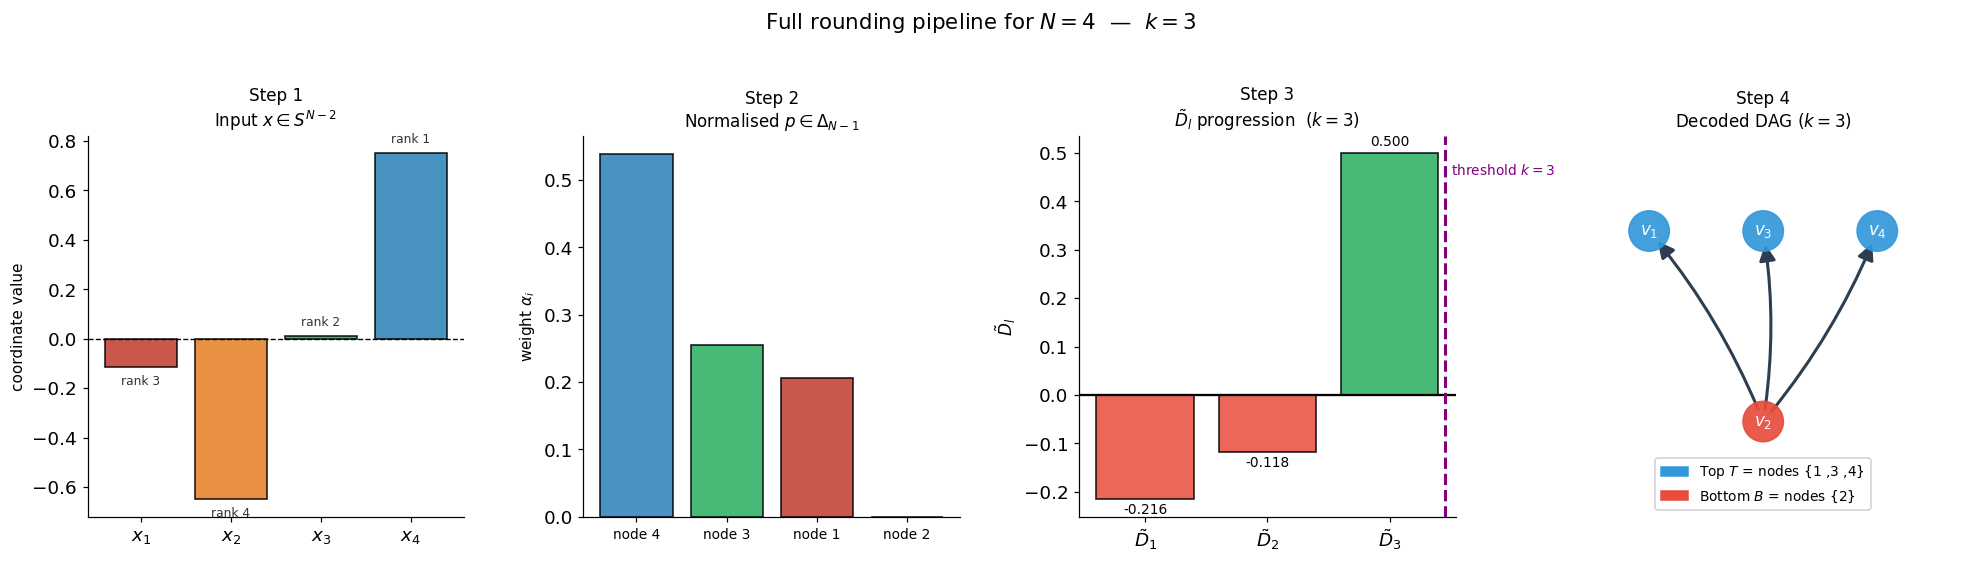

x          = [-0.114 -0.65   0.013  0.751]
sigma      = ['node 4', 'node 3', 'node 1', 'node 2']  (sorted by x, descending)
p          = [0.539 0.255 0.206 0.   ]
D̃ values  = [-0.216 -0.118  0.5  ]
k          = 3
Top    T   = {nodes {np.int64(1), np.int64(3), np.int64(4)}}
Bottom B   = {nodes {np.int64(2)}}
Edges      = [(2, 4), (2, 3), (2, 1)]


In [5]:
N = 4

# Random point on S^{N-2} ⊂ H₀
raw = np.random.randn(N)
raw -= raw.mean()                    # project to H₀
x   = raw / np.linalg.norm(raw)      # normalise to sphere

res = rounding_map(x)
sigma, p, k = res['sigma'], res['p'], res['k']

# Compute all D̃_l values for the trace
ps = p.copy()                        # already sorted descending
D_trace = []
D = ps[0] - ps[1] - 0.5             # D̃_1
D_trace.append(D)
for l in range(1, N-1):             # D̃_2 … D̃_{N-1}
    nxt = ps[l+1] if l+1 < N else 0.0
    D += (l+1) * (ps[l] - nxt)
    D_trace.append(D)
D_trace = np.array(D_trace)         # D̃_1, D̃_2, …, D̃_{N-1}

# ── figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'Full rounding pipeline for $N={N}$  —  $k={k}$',
             fontsize=14, y=1.02)

node_base = ['#c0392b','#e67e22','#27ae60','#2980b9']

# ── panel 1: input x ─────────────────────────────────────────────────────────
ax1 = axes[0]
bar_cols = [node_base[i % 4] for i in range(N)]
ax1.bar(range(1, N+1), x, color=bar_cols, edgecolor='black', lw=1.1, alpha=0.85)
ax1.axhline(0, color='black', lw=0.9, ls='--')
ax1.set_xticks(range(1, N+1))
ax1.set_xticklabels([f'$x_{i}$' for i in range(1, N+1)], fontsize=12)
for i in range(N):
    rank = np.where(sigma == i)[0][0] + 1
    yoff = 0.04 if x[i] >= 0 else -0.07
    ax1.text(i+1, x[i]+yoff, f'rank {rank}', ha='center', fontsize=8, color='#333')
ax1.set_title('Step 1\nInput $x \\in S^{N-2}$', fontsize=11)
ax1.set_ylabel('coordinate value', fontsize=10)
ax1.spines[['top','right']].set_visible(False)

# ── panel 2: normalised p ─────────────────────────────────────────────────────
ax2 = axes[1]
p_bar_cols = [node_base[sigma[l] % 4] for l in range(N)]
ax2.bar(range(1, N+1), p, color=p_bar_cols, edgecolor='black', lw=1.1, alpha=0.85)
ax2.set_xticks(range(1, N+1))
ax2.set_xticklabels([f'node {sigma[l]+1}' for l in range(N)], fontsize=9)
ax2.set_title('Step 2\nNormalised $p \\in \\Delta_{N-1}$', fontsize=11)
ax2.set_ylabel('weight $\\alpha_i$', fontsize=10)
ax2.spines[['top','right']].set_visible(False)

# ── panel 3: D̃_l values ──────────────────────────────────────────────────────
ax3 = axes[2]
ls = range(1, N)                    # l = 1, …, N-1
d_cols = ['#27ae60' if d >= 0 else '#e74c3c' for d in D_trace]
bars = ax3.bar(ls, D_trace, color=d_cols, edgecolor='black', lw=1.1, alpha=0.85)
ax3.axhline(0, color='black', lw=1.5)
ax3.set_xticks(list(ls))
ax3.set_xticklabels([f'$\\tilde{{D}}_{l}$' for l in ls], fontsize=12)
for l, d in zip(ls, D_trace):
    yoff = 0.015 if d >= 0 else -0.03
    ax3.text(l, d + yoff, f'{d:.3f}', ha='center', fontsize=9)
# Mark threshold
if k <= N-1:
    ax3.axvline(k + 0.45, color='purple', lw=2, ls='--')
    ax3.text(k + 0.5, ax3.get_ylim()[1]*0.85, f'threshold $k={k}$',
             color='purple', fontsize=9)
ax3.set_title(f'Step 3\n$\\tilde{{D}}_l$ progression  ($k={k}$)', fontsize=11)
ax3.set_ylabel('$\\tilde{D}_l$', fontsize=11)
ax3.spines[['top','right']].set_visible(False)

# ── panel 4: decoded DAG ──────────────────────────────────────────────────────
ax4 = axes[3]
draw_dag(ax4, N, res, title=f'Step 4\nDecoded DAG ($k={k}$)')

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig3_pipeline_trace.pdf', bbox_inches='tight')
plt.savefig(f'{FIGDIR}/fig3_pipeline_trace.png', bbox_inches='tight', dpi=150)
print(f'Saved: {FIGDIR}/fig3_pipeline_trace.pdf  +  .png')
plt.show()

# Print summary
print(f'x          = {np.round(x,3)}')
print(f'sigma      = {[f"node {s+1}" for s in sigma]}  (sorted by x, descending)')
print(f'p          = {np.round(p,3)}')
print(f'D̃ values  = {np.round(D_trace,3)}')
print(f'k          = {k}')
print(f'Top    T   = {{nodes {set(t+1 for t in res["top"])}}}')
print(f'Bottom B   = {{nodes {set(b+1 for b in res["bottom"])}}}')
print(f'Edges      = {[(b+1,t+1) for b,t in res["edges"]]}')